In [167]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.2' 

%matplotlib widget
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from temgym_core.components import Detector
from temgym_core.utils import  energy2wavelength
from temgym_core.gaussian import make_gaussian_plane_wave_round_aperture
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper, evaluate_gaussians_jax_scan
from temgym_core.gaussian_taylor import (
    Lens,
    SigmoidAperture,
    KrivanekLens,
    run_to_end,

)
from temgym_core.utils import FresnelPropagator
from temgym_core.aberrations import KrivanekCoeffs

jax.config.update("jax_enable_x64", True)

In [168]:
voltage = 300000  # in volts
wavelength = energy2wavelength(voltage)  # in meters
input_window_width = 2e-6
aperture_radius = 0.5e-6
aperture_window_width = input_window_width
lens_f = 1e-2

Nx = Ny = 512
input_aperture_pixel_size_x = input_window_width/Nx
input_aperture_pixel_size_y = input_window_width/Ny

output_aperture_pixel_size_bfp_xy = wavelength * abs(lens_f) / (aperture_window_width)

input_aperture_grid = Detector(z=0.0, pixel_size=(input_aperture_pixel_size_x, input_aperture_pixel_size_y), shape=(Nx, Ny))

input_extent = input_aperture_grid.extent

aperture = SigmoidAperture(radius=aperture_radius, sharpness=10, z=0.0, t_outside=0.0)

In [169]:
w0 = 2e-9
rays_in, wavelength, k0 = make_gaussian_plane_wave_round_aperture(
    voltage=voltage,
    aperture_radius=aperture.radius,
    waist_radius=w0,
    num_rays=120000,
    normalization='flux',
)
rays_in = rays_in.to_vector()

run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)),
    static_argnums=(1,),
)


In [170]:
# Aberration coefficients
C_sph = 0
C_coma_x = 0
C_coma_y = 0
coeffs = KrivanekCoeffs(
    C30=C_sph,
    C21=C_coma_x,
    phi21=0.0,
    C23=C_coma_y,
    phi23=0.5 * jnp.pi,
)


In [171]:
aberrated_lens = KrivanekLens(focal_length=lens_f, coeffs=coeffs, z=lens_f)
output_probe_grid = Detector(z=lens_f, pixel_size=(output_aperture_pixel_size_bfp_xy, output_aperture_pixel_size_bfp_xy), shape=(Nx, Ny))
output_extent = output_probe_grid.extent
output_x, output_y = output_probe_grid.coords_1d
input_components = (aperture, aberrated_lens)
rays_after_input_aperture = run_to_end_vmapped(rays_in, input_components)

total_components = input_components + (output_probe_grid,)
rays_out = run_to_end_vmapped(rays_in, total_components)

In [172]:
input_aperture = evaluate_gaussians_gpu_kernel_wrapper(rays_after_input_aperture, input_aperture_grid).block_until_ready()
output_aperture = evaluate_gaussians_gpu_kernel_wrapper(rays_out, output_probe_grid).block_until_ready()

In [173]:
rays_after_input_aperture.x
rays_out.x

Array([ 0.00000000e+00, -1.30538507e-09,  1.99810108e-10, ...,
        7.96193670e-08,  2.74726711e-07, -4.84769221e-07], dtype=float64)

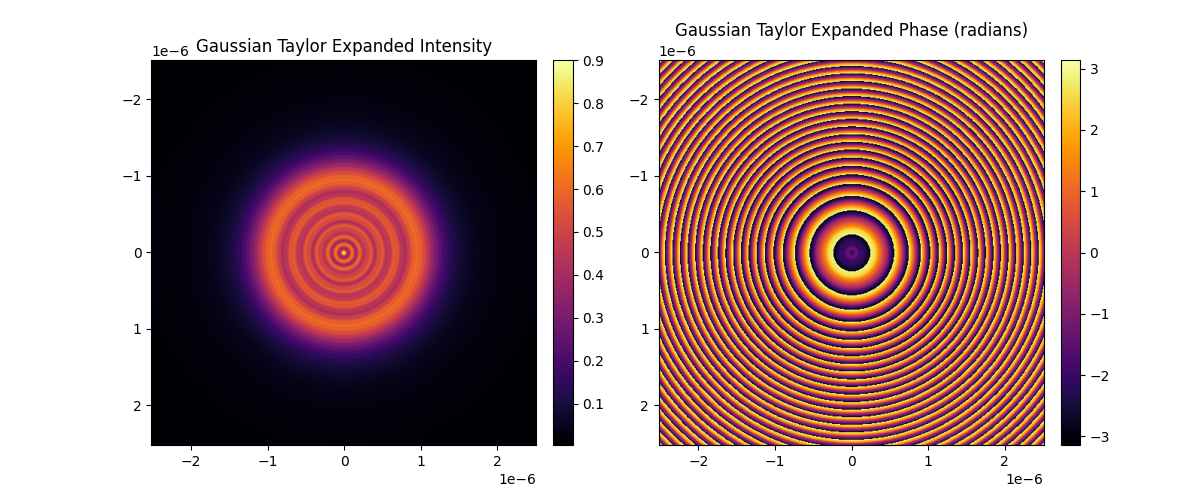

In [174]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(jnp.abs(input_aperture), extent=output_extent, cmap='inferno')
axes[0].set_title('Gaussian Taylor Expanded Intensity')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(jnp.angle(input_aperture), extent=output_extent, cmap='inferno')
axes[1].set_title('Gaussian Taylor Expanded Phase (radians)')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

In [175]:
# du, dv = input_aperture_pixel_size_x, input_aperture_pixel_size_y
# fft_field = jnp.fft.ifftshift(jnp.fft.fft2(input_aperture))
# diffraction_of_aperture = fft_field * (du * dv) / (1j * wavelength * lens_f)
# det_image_in_focus = diffraction_of_aperture

diffraction_of_aperture = FresnelPropagator(
    u1=input_aperture,
    wavelength=wavelength,
    z=lens_f,
    L=input_window_width,
)

probe_image_np = np.asarray(output_aperture)
fft_image_np = np.asarray(diffraction_of_aperture)


Text(0.5, 1.0, 'FFT propagation intensity')

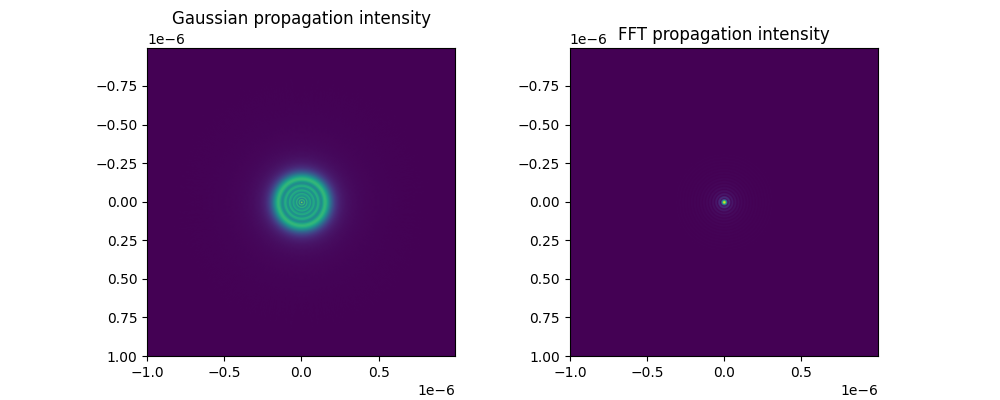

In [176]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(np.abs(probe_image_np), extent=input_extent)
ax[0].set_title('Gaussian propagation intensity')
ax[1].imshow(np.abs(fft_image_np), extent=input_extent)
ax[1].set_title('FFT propagation intensity')


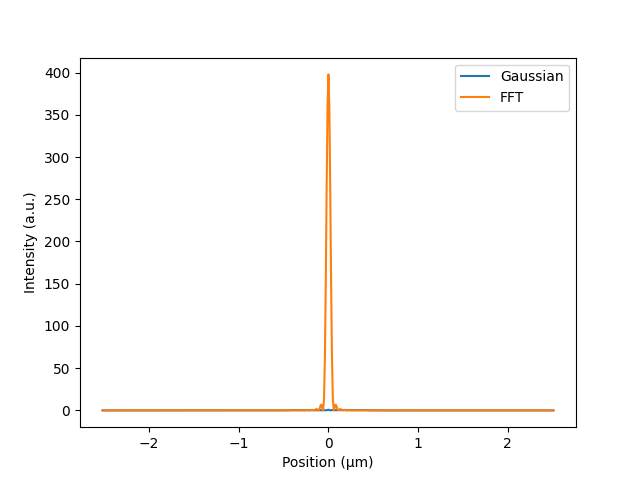

In [177]:
plt.figure()
plt.plot(output_x * 1e6, np.abs(probe_image_np[Nx//2, :])**2, label='Gaussian')
plt.plot(output_x * 1e6, np.abs(fft_image_np[Nx//2, :])**2, label='FFT')
plt.xlabel('Position (µm)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
